# Branch A — BiLSTM Training
Run on GPU runtime in Google Colab.

In [1]:
# Cell 1 — Clone repo and set path
import os, sys

if not os.path.exists('/content/hallucination-detector'):
    !git clone https://github.com/theek-sh-nahh/hallucination-detector.git
else:
    !cd /content/hallucination-detector && git pull origin main

os.chdir('/content/hallucination-detector')
sys.path.insert(0, '/content/hallucination-detector')

# Verify src is visible
print('Repo contents:',   os.listdir('/content/hallucination-detector'))
print('src contents:',    os.listdir('/content/hallucination-detector/src'))
print('sys.path[0]:',     sys.path[0])

Cloning into 'hallucination-detector'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 41 (delta 19), reused 30 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 30.75 KiB | 6.15 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Repo contents: ['notebooks', 'README.md', 'src', 'requirements.txt', 'app', '.gitignore', '.git']
src contents: ['fusion.py', 'confidence.py', 'autoencoder.py', 'lstm_model.py', 'preprocess.py', '__init__.py']
sys.path[0]: /content/hallucination-detector


In [2]:
# Cell 2 — Install dependencies
!pip install -q sentence-transformers imbalanced-learn
print('Done.')

Done.


In [3]:
# Cell 3 — Upload processed_data.zip
from google.colab import files
import zipfile, os

print('Upload processed_data.zip now:')
uploaded = files.upload()

os.makedirs('/content/hallucination-detector/data/processed', exist_ok=True)
with zipfile.ZipFile('processed_data.zip', 'r') as z:
    z.extractall('/content/hallucination-detector/data/processed')

print('Extracted files:')
print(os.listdir('/content/hallucination-detector/data/processed'))

Upload processed_data.zip now:


Saving processed_data.zip to processed_data.zip
Extracted files:
['y_test.npy', 'X_test.npy', 'y_train.npy', 'X_train.npy', 'X_val.npy', 'dataset.csv', 'y_val.npy']


In [4]:
# Cell 4 — Load data and verify GPU
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

base    = '/content/hallucination-detector/data/processed'
X_train = np.load(f'{base}/X_train.npy')
X_val   = np.load(f'{base}/X_val.npy')
y_train = np.load(f'{base}/y_train.npy')
y_val   = np.load(f'{base}/y_val.npy')

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Device: cuda
X_train: (4116, 384), y_train: (4116,)
Classes: {np.int64(0): np.int64(1811), np.int64(1): np.int64(1201), np.int64(2): np.int64(9), np.int64(3): np.int64(1095)}


In [5]:
# Cell 5 — SMOTE balancing
from imblearn.over_sampling import SMOTE

print('Before SMOTE:', dict(zip(*np.unique(y_train, return_counts=True))))

smote = SMOTE(
    sampling_strategy={0: 1811, 1: 1201, 2: 800, 3: 1095},
    k_neighbors=3,
    random_state=42
)
X_train, y_train = smote.fit_resample(X_train, y_train)

print('After SMOTE: ', dict(zip(*np.unique(y_train, return_counts=True))))
print(f'X_train shape: {X_train.shape}')

Before SMOTE: {np.int64(0): np.int64(1811), np.int64(1): np.int64(1201), np.int64(2): np.int64(9), np.int64(3): np.int64(1095)}
After SMOTE:  {np.int64(0): np.int64(1811), np.int64(1): np.int64(1201), np.int64(2): np.int64(800), np.int64(3): np.int64(1095)}
X_train shape: (4907, 384)


In [7]:
import sys
# Clear cached module
mods = [k for k in sys.modules if 'src' in k or 'lstm' in k]
for m in mods:
    del sys.modules[m]

!cd /content/hallucination-detector && git pull origin main
print("Done.")

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 450 bytes | 56.00 KiB/s, done.
From https://github.com/theek-sh-nahh/hallucination-detector
 * branch            main       -> FETCH_HEAD
   4082163..2e81029  main       -> origin/main
Updating 4082163..2e81029
Fast-forward
 src/autoencoder.py | 2 +-
 src/lstm_model.py  | 7 ++++++-
 2 files changed, 7 insertions(+), 2 deletions(-)
Done.


In [8]:
# Cell 6 — Run hyperparameter search
from src.lstm_model import run_hyperparameter_search

save_dir = '/content/hallucination-detector/models/lstm'

best_config, results = run_hyperparameter_search(
    X_train, X_val, y_train, y_val,
    device=device,
    save_dir=save_dir
)
print(f'\nBest config: {best_config}')


HYPERPARAMETER SEARCH — 16 configurations

[1/16] Config: {'lr': 0.001, 'dropout': 0.3, 'hidden_dim': 128, 'batch_size': 32, 'epochs': 30, 'patience': 5}
  Train batches: 154, Val batches: 28
  Class weights: {0: np.float64(0.623), 1: np.float64(0.939), 2: np.float64(1.409), 3: np.float64(1.03)}

  Training for up to 30 epochs...
  LR=0.001, Dropout=0.3, Batch=32
-------------------------------------------------------
  Epoch 001 | Train Loss: 1.0273 Acc: 0.3913 | Val Loss: 1.1134 Acc: 0.3601
  ✓ Best model saved (val_loss=1.1134)
  Epoch 002 | Train Loss: 0.8060 Acc: 0.4991 | Val Loss: 1.0485 Acc: 0.4100
  ✓ Best model saved (val_loss=1.0485)
  Epoch 003 | Train Loss: 0.7416 Acc: 0.5343 | Val Loss: 1.0096 Acc: 0.4496
  ✓ Best model saved (val_loss=1.0096)
  Epoch 004 | Train Loss: 0.7072 Acc: 0.5549 | Val Loss: 0.9953 Acc: 0.4553
  ✓ Best model saved (val_loss=0.9953)
  Epoch 005 | Train Loss: 0.6918 Acc: 0.5702 | Val Loss: 1.0325 Acc: 0.4258
  Epoch 006 | Train Loss: 0.6755 Acc: 0.5

In [9]:
# Cell 7 — Train final model with best config
from src.lstm_model import (
    BiLSTMClassifier, prepare_dataloaders, train_model
)

final_config = best_config.copy()
final_config['epochs']   = 60
final_config['patience'] = 7

train_loader, val_loader = prepare_dataloaders(
    X_train, X_val, y_train, y_val,
    batch_size=final_config['batch_size']
)

model = BiLSTMClassifier(
    input_dim=384,
    hidden_dim=final_config['hidden_dim'],
    num_layers=2,
    num_classes=4,
    dropout=final_config['dropout']
).to(device)

history = train_model(
    model, train_loader, val_loader,
    final_config, device,
    save_path=f'{save_dir}/lstm_final.pt'
)
print('Final model training complete.')

  Train batches: 77, Val batches: 14
  Class weights: {0: np.float64(0.623), 1: np.float64(0.939), 2: np.float64(1.409), 3: np.float64(1.03)}

  Training for up to 60 epochs...
  LR=0.0005, Dropout=0.4, Batch=64
-------------------------------------------------------
  Epoch 001 | Train Loss: 1.3189 Acc: 0.3442 | Val Loss: 1.3280 Acc: 0.3511
  ✓ Best model saved (val_loss=1.3280)
  Epoch 002 | Train Loss: 0.9157 Acc: 0.4300 | Val Loss: 1.1298 Acc: 0.3148
  ✓ Best model saved (val_loss=1.1298)
  Epoch 003 | Train Loss: 0.8454 Acc: 0.4455 | Val Loss: 1.1262 Acc: 0.3431
  ✓ Best model saved (val_loss=1.1262)
  Epoch 004 | Train Loss: 0.8217 Acc: 0.4769 | Val Loss: 1.1116 Acc: 0.3998
  ✓ Best model saved (val_loss=1.1116)
  Epoch 005 | Train Loss: 0.7964 Acc: 0.5076 | Val Loss: 1.0800 Acc: 0.3862
  ✓ Best model saved (val_loss=1.0800)
  Epoch 006 | Train Loss: 0.7701 Acc: 0.5178 | Val Loss: 1.0512 Acc: 0.3975
  ✓ Best model saved (val_loss=1.0512)
  Epoch 007 | Train Loss: 0.7509 Acc: 0.52

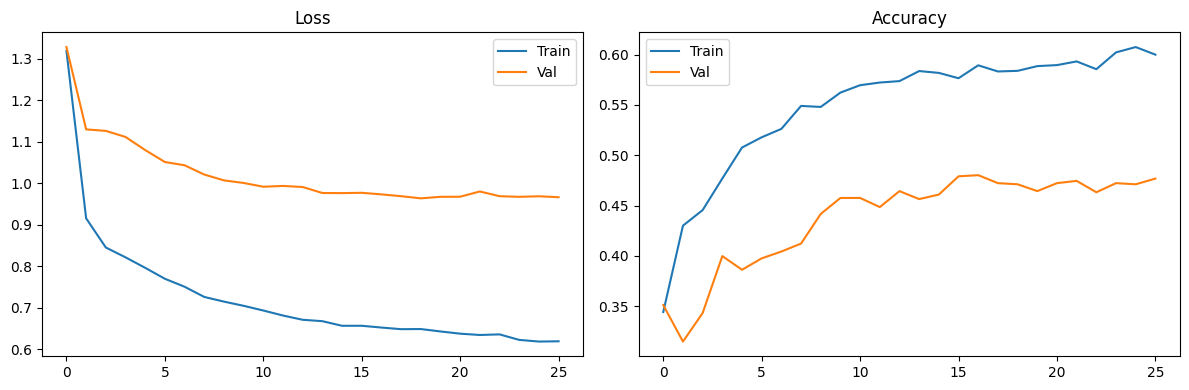

Plot saved.


In [10]:
# Cell 8 — Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(f'{save_dir}/training_plot.png', dpi=150)
plt.show()
print('Plot saved.')

In [11]:
# Cell 9 — Download trained model
import shutil
from google.colab import files

shutil.make_archive('lstm_model', 'zip',
    '/content/hallucination-detector/models/lstm')
files.download('lstm_model.zip')
print('Download started.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
